In [62]:
import pandas as pd
from sklearn.cluster import KMeans

In [63]:

mov_h = pd.read_csv("/Users/fangsiyu/Desktop/Kolding Hackathon 2026/n_data/movement_stats_hourly.csv")
sd_h = pd.read_csv("/Users/fangsiyu/Desktop/Kolding Hackathon 2026/n_data/stay_duration_stats_hourly.csv")

mov_h['sensor'] = mov_h['sensor'].str.extract(r'(\d+\.\d+)')
sd_h = sd_h.drop(columns=['Unnamed: 0'])
sd_h


,sensor,category,sum_ms,min_ms,max_ms,objects,timestamp
0,12-Zone 1 - Duration of occurrence - Table,wheelchair,21360,6240,15120,2,2026-02-09T15:00:00+01:00
1,12-Zone 1 - Duration of occurrence - Table,van,535600,8560,329360,4,2026-02-09T15:00:00+01:00
2,12-Zone 1 - Duration of occurrence - Table,scooter,16040,6800,9240,2,2026-02-09T15:00:00+01:00
3,12-Zone 1 - Duration of occurrence - Table,pram,143680,3040,18120,22,2026-02-09T15:00:00+01:00
4,12-Zone 1 - Duration of occurrence - Table,pedestrian,7314036,3080,597560,409,2026-02-09T15:00:00+01:00
...,...,...,...,...,...,...,...
27753,12-Zone 1 - Duration of occurrence - Table,pedestrian,81760,3160,8520,16,2026-05-08T07:00:00+02:00
27754,12-Zone 1 - Duration of occurrence - Table,car trailer,3160,3160,3160,1,2026-05-08T07:00:00+02:00
27755,12-Zone 1 - Duration of occurrence - Table,car,551719,3080,8440,112,2026-05-08T07:00:00+02:00
27756,12-Zone 1 - Duration of occurrence - Table,bicycle,3040,3040,3040,1,2026-05-08T07:00:00+02:00


In [64]:
df_mix_gate = pd.read_csv('/Users/fangsiyu/Desktop/Kolding Hackathon 2026/mov_h_net_flow_by_mix_gate_without3-1.csv')
df_mix_gate.columns # Index(['timestamp', 'category', 'IN', 'OUT', 'net_inflow'], dtype='object')


Index(['timestamp', 'category', 'IN', 'OUT', 'net_inflow'], dtype='object')

In [65]:
# df_keep_zone1 = 
sd_mask = sd_h['sensor'] == '12-Zone 1 - Duration of occurrence - Table'
zone1_df = sd_h[sd_mask].copy()

pivot_df = zone1_df.pivot_table(
    index='timestamp', 
    columns='category', 
    values= ['sum_ms', 'min_ms', 'max_ms'], 
    aggfunc={
        'sum_ms': 'sum',
        'min_ms': 'min',
        'max_ms': 'max'
    }
).fillna(0)

pivot_df.columns = [f"dur_{metric}_{category}" for metric, category in pivot_df.columns]
df_keep_zone1 = pivot_df.reset_index()
# df_keep_zone1.to_csv('/Users/fangsiyu/Desktop/Kolding Hackathon 2026/dur_h_zone2_pivot.csv', index=False, encoding='utf-8-sig')

df_keep_zone1.columns

Index(['timestamp', 'dur_max_ms_animal', 'dur_max_ms_bicycle',
       'dur_max_ms_bus', 'dur_max_ms_car', 'dur_max_ms_car trailer',
       'dur_max_ms_caravan', 'dur_max_ms_heavy', 'dur_max_ms_light',
       'dur_max_ms_motorcycle', 'dur_max_ms_pedestrian', 'dur_max_ms_pram',
       'dur_max_ms_scooter', 'dur_max_ms_tractor', 'dur_max_ms_tram',
       'dur_max_ms_truck trailer', 'dur_max_ms_van', 'dur_max_ms_wheelchair',
       'dur_min_ms_animal', 'dur_min_ms_bicycle', 'dur_min_ms_bus',
       'dur_min_ms_car', 'dur_min_ms_car trailer', 'dur_min_ms_caravan',
       'dur_min_ms_heavy', 'dur_min_ms_light', 'dur_min_ms_motorcycle',
       'dur_min_ms_pedestrian', 'dur_min_ms_pram', 'dur_min_ms_scooter',
       'dur_min_ms_tractor', 'dur_min_ms_tram', 'dur_min_ms_truck trailer',
       'dur_min_ms_van', 'dur_min_ms_wheelchair', 'dur_sum_ms_animal',
       'dur_sum_ms_bicycle', 'dur_sum_ms_bus', 'dur_sum_ms_car',
       'dur_sum_ms_car trailer', 'dur_sum_ms_caravan', 'dur_sum_ms_heavy',
  

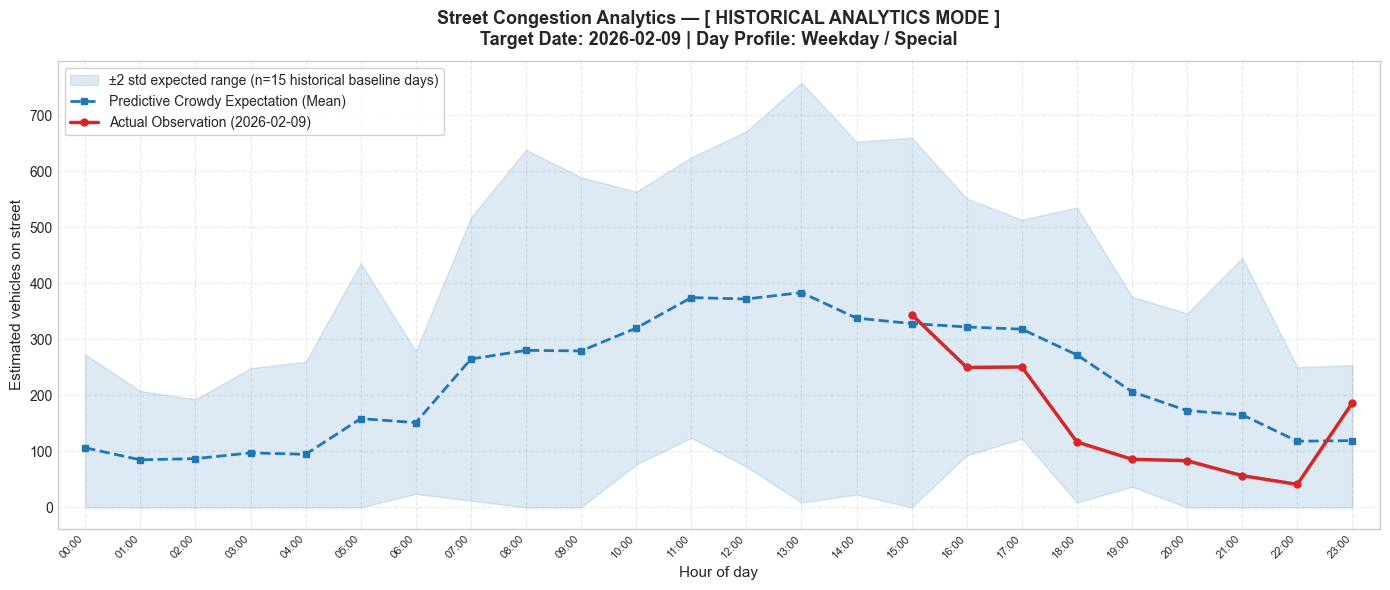


── Baseline sample counts per group ──
group
weekday_regular    50
weekday_special    15
weekend_regular    15
weekend_special     9


In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── 0. 設定 ────────────────────────────────────────────────────────────
# 💡 支援未來日期！你可以設定為超出目前 index 的未來（例如 "2026-05-20"）
TARGET_DATE = "2026-02-09"  # None = 自動取最新一天；可設歷史或未來日期
SPECIAL_WEIGHT = 0.7        # zone 資料權重
GATE_WEIGHT    = 0.3        # gate 資料權重

# 保留有意義的車種（排除 tractor/tram/animal/pram/scooter 等稀少噪音）
VEHICLE_TYPES = ['car', 'bus', 'van', 'motorcycle', 'heavy', 'light', 'truck trailer']

# ── 1. 時區轉換 ────────────────────────────────────────────────────────
for df in [df_keep_zone1, df_mix_gate]:
    df['timestamp'] = (
        pd.to_datetime(df['timestamp'], utc=True)
        .dt.tz_convert('Europe/Copenhagen')
    )

# ── 2. Zone：排隊理論估算街上車輛數（dur_sum / dur_min） ───────────────
SUM_COLS = [f'dur_sum_ms_{v}' for v in VEHICLE_TYPES if f'dur_sum_ms_{v}' in df_keep_zone1.columns]
MIN_COLS = [f'dur_min_ms_{v}' for v in VEHICLE_TYPES if f'dur_min_ms_{v}' in df_keep_zone1.columns]

zone = df_keep_zone1[['timestamp']].copy()

for s_col, m_col in zip(SUM_COLS, MIN_COLS):
    v = s_col.replace('dur_sum_ms_', '')
    zone[f'veh_{v}'] = np.where(
        df_keep_zone1[m_col] > 0,
        df_keep_zone1[s_col] / df_keep_zone1[m_col],
        np.nan          # 沒有資料 → NaN，不污染加總
    )

veh_cols = [f'veh_{v}' for v in VEHICLE_TYPES if f'veh_{v}' in zone.columns]
zone['vehicles_on_street'] = zone[veh_cols].sum(axis=1, min_count=1)  # min_count=1：全NaN行保持NaN

zone['date']    = zone['timestamp'].dt.date
zone['hour']    = zone['timestamp'].dt.hour
zone['weekday'] = zone['timestamp'].dt.dayofweek   # 0=Mon … 6=Sun

# ── 3. Gate：只用 IN（流入量，避免 IN+OUT 雙重計算） ──────────────────
gate_hourly = (
    df_mix_gate
    .groupby('timestamp')[['IN']]
    .sum()
    .reset_index()
)

zone = zone.merge(gate_hourly, on='timestamp', how='left')
zone['IN'] = zone['IN'].fillna(0)

# ── 4. 雙感測器融合（Z-score → 加權合成 → 反標準化回車輛數尺度） ──────
def z_score(series):
    mu, sd = series.mean(), series.std()
    return (series - mu) / (sd + 1e-9), mu, sd

zone['veh_z'],  mu_v, sd_v  = z_score(zone['vehicles_on_street'])
zone['veh_z'] = zone['veh_z'].fillna(0)
zone['IN_z'],   _,    _     = z_score(zone['IN'])

zone['congestion_score'] = (
    zone['veh_z'] * SPECIAL_WEIGHT + zone['IN_z'] * GATE_WEIGHT
)
zone['congestion_score'] = (zone['congestion_score'] * sd_v + mu_v).clip(lower=0)

# ── 5. 特殊日標籤（ellie.csv） ─────────────────────────────────────────
special_event_dates = {
    "2026-02-07","2026-02-08","2026-02-09","2026-02-10","2026-02-11",
    "2026-02-12","2026-02-13","2026-02-14","2026-02-15","2026-02-26",
    "2026-03-08","2026-03-24","2026-03-28","2026-03-29","2026-03-30",
    "2026-03-31","2026-04-01","2026-04-02","2026-04-03","2026-04-04",
    "2026-04-05","2026-04-06","2026-04-12","2026-04-25","2026-05-01",
    "2026-05-06"
}
event_dates_set = set(pd.to_datetime(list(special_event_dates)).date)
zone['is_special'] = zone['date'].apply(lambda x: 1 if x in event_dates_set else 0)

# ── 6. 分組方式：weekday type × is_special（4 種 baseline） ────────────
zone['day_type'] = np.where(zone['weekday'] >= 5, 'weekend', 'weekday')
zone['group'] = zone['day_type'] + '_' + zone['is_special'].map({0:'regular', 1:'special'})

hourly_stats = (
    zone.groupby(['group', 'hour'])['congestion_score']
    .agg(mean='mean', std='std', n='count')
    .reset_index()
)
hourly_stats['upper'] = hourly_stats['mean'] + 2 * hourly_stats['std']
hourly_stats['lower'] = (hourly_stats['mean'] - 2 * hourly_stats['std']).clip(lower=0)

# ── 7. 【核心升級】決定目標日期：支援未來日期的動態日曆推算 ────────────────
if TARGET_DATE is None:
    target_date = zone['date'].max()
    is_future = False
else:
    target_date = pd.to_datetime(TARGET_DATE).date()
    is_future = target_date > zone['date'].max()

# 💡 關鍵改動：不從歷史 zone 查表，直接用 datetime 推算該日期的屬性
target_dt = pd.to_datetime(target_date)
target_weekday = target_dt.dayofweek
target_day_type = 'weekend' if target_weekday >= 5 else 'weekday'
target_is_special = 1 if target_date in event_dates_set else 0
target_group = f"{target_day_type}_{'special' if target_is_special == 1 else 'regular'}"

# 計算該 group 在歷史中由幾天建立而成
n_days_in_group = zone[zone['group'] == target_group]['date'].nunique()

# 提取對應的歷史統計基線
baseline = (
    hourly_stats[hourly_stats['group'] == target_group]
    .sort_values('hour')
    .set_index('hour')
    .reindex(range(24))
)

# 判斷實際觀測值 (如果是未來，則全為 NaN 斷線不畫)
if is_future:
    actual = pd.Series([np.nan] * 24, index=range(24))
else:
    actual = (
        zone[zone['date'] == target_date]
        .set_index('hour')['congestion_score']
        .reindex(range(24))
    )

# ── 8. 繪圖 (智慧偵測未來模式) ──────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, ax = plt.subplots(figsize=(14, 6))

# A. 歷史預期陰影帶
ax.fill_between(
    range(24), baseline['lower'], baseline['upper'],
    alpha=0.15, color='#1f77b4',
    label=f'±2 std expected range (n={n_days_in_group} historical baseline days)'
)

# B. 歷史均值預測線 (未來擁擠度期望值)
ax.plot(
    range(24), baseline['mean'],
    color='#1f77b4', linewidth=2, linestyle='--', marker='s', markersize=4,
    label='Predictive Crowdy Expectation (Mean)'
)

# C. 實際觀測線（僅在日期屬於歷史時才繪製）
if not is_future and actual.notna().any():
    ax.plot(
        range(24), actual.values,
        color='#d62728', linewidth=2.5, marker='o', markersize=5,
        label=f'Actual Observation ({target_date})'
    )
    
    # 超出上限標記 (歷史模式下的壅塞告警)
    congested_hours = [h for h in range(24)
                       if pd.notna(actual.iloc[h])
                       and pd.notna(baseline['upper'].iloc[h])
                       and actual.iloc[h] > baseline['upper'].iloc[h]]
    if congested_hours:
        ax.scatter(
            congested_hours, actual.iloc[congested_hours].values,
            color='#d62728', s=80, zorder=5, marker='^', label='Above expected (congested)'
        )

# 依據是否為未來動態調整標題
group_label = target_group.replace('_', ' / ').title()
mode_title = "[ FUTURE FORECAST MODE ]" if is_future else "[ HISTORICAL ANALYTICS MODE ]"

ax.set_title(
    f'Street Congestion Analytics — {mode_title}\n'
    f'Target Date: {target_date} | Day Profile: {group_label}',
    fontsize=13, fontweight='bold', pad=12
)
ax.set_xlabel('Hour of day', fontsize=11)
ax.set_ylabel('Estimated vehicles on street', fontsize=11)
ax.set_xticks(range(24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, ha='right', fontsize=8)
ax.set_xlim(-0.5, 23.5)
ax.legend(fontsize=10, loc='upper left', frameon=True, facecolor='white', framealpha=0.9)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('congestion_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 9. 快速診斷：印出各 group 的樣本數 ───────────────────────────────
print("\n── Baseline sample counts per group ──")
print(zone.groupby('group')['date'].nunique().rename('n_days').to_string())
if is_future:
    print(f"\n💡 系統提示：偵測到目標日期 {target_date} 屬於未來。已自動載入歷史 {group_label} 基線進行預測外推！")

In [ ]:
import pandas as pd
import numpy as np

# =====================================================================
# 步驟 0：每次執行都重新從最乾淨的原生 DataFrame 複製，徹底切斷快取污染
# =====================================================================
# 確保原始資料的時區正確轉換為丹麥當地時間
df_keep_zone1['timestamp'] = pd.to_datetime(df_keep_zone1['timestamp'], utc=True).dt.tz_convert('Europe/Copenhagen')
df_mix_gate['timestamp'] = pd.to_datetime(df_mix_gate['timestamp'], utc=True).dt.tz_convert('Europe/Copenhagen')

# 重新初始化乾淨的 zone 表，並把你要驗證的 pedestrian 撈過來
zone = df_keep_zone1[['timestamp', 'dur_sum_ms_pedestrian']].copy()

# =====================================================================
# 步驟 1：重新計算排隊理論與雙感測器融合的 congestion_score
# =====================================================================
VEHICLE_TYPES = ['car', 'bus', 'van', 'motorcycle', 'heavy', 'light', 'truck trailer']
SUM_COLS = [f'dur_sum_ms_{v}' for v in VEHICLE_TYPES if f'dur_sum_ms_{v}' in df_keep_zone1.columns]
MIN_COLS = [f'dur_min_ms_{v}' for v in VEHICLE_TYPES if f'dur_min_ms_{v}' in df_keep_zone1.columns]

for s_col, m_col in zip(SUM_COLS, MIN_COLS):
    v = s_col.replace('dur_sum_ms_', '')
    zone[f'veh_{v}'] = np.where(df_keep_zone1[m_col] > 0, df_keep_zone1[s_col] / df_keep_zone1[m_col], np.nan)

veh_cols = [f'veh_{v}' for v in VEHICLE_TYPES if f'veh_{v}' in zone.columns]
zone['vehicles_on_street'] = zone[veh_cols].sum(axis=1, min_count=1)

# 融合 Gate 的流入量 (IN)
gate_hourly = df_mix_gate.groupby('timestamp')[['IN']].sum().reset_index()
zone = zone.merge(gate_hourly, on='timestamp', how='left')
zone['IN'] = zone['IN'].fillna(0)

# 計算特徵得分
def z_score(series):
    mu, sd = series.mean(), series.std()
    return (series - mu) / (sd + 1e-9), mu, sd

zone['veh_z'], mu_v, sd_v = z_score(zone['vehicles_on_street'])
zone['veh_z'] = zone['veh_z'].fillna(0)
zone['IN_z'], _, _ = z_score(zone['IN'])

zone['congestion_score'] = zone['veh_z'] * 0.7 + zone['IN_z'] * 0.3
zone['congestion_score'] = (zone['congestion_score'] * sd_v + mu_v).clip(lower=0)

# 建立對齊用的字串格式
zone['date_str'] = zone['timestamp'].dt.strftime('%Y-%m-%d')
zone['hour'] = zone['timestamp'].dt.hour


# =====================================================================
# 步驟 2：載入大眾運輸高密度資料並精準提取小時 (適應 4:35 與 14:35)
# =====================================================================
trains = pd.read_csv("/Users/fangsiyu/Desktop/Kolding Hackathon 2026/K_daily_trains_feb7_may20.csv")
buses = pd.read_csv("/Users/fangsiyu/Desktop/Kolding Hackathon 2026/K_daily_buses_feb7_may20.csv")

# 使用冒號安全切分小時，防止 "4:" 錯誤，並做型態防禦
trains['hour'] = pd.to_numeric(trains['arrival_time'].str.split(':').str[0], errors='coerce').fillna(0).astype(int)
buses['hour'] = pd.to_numeric(buses['arrival_time'].str.split(':').str[0], errors='coerce').fillna(0).astype(int)

trains['date_str'] = pd.to_datetime(trains['exact_date']).dt.strftime('%Y-%m-%d')
buses['date_str'] = pd.to_datetime(buses['exact_date']).dt.strftime('%Y-%m-%d')


# =====================================================================
# 步驟 3：按小時計算班次總數並無縫 merge
# =====================================================================
hourly_trains = trains.groupby(['date_str', 'hour']).size().rename('train_count').reset_index()
hourly_buses = buses.groupby(['date_str', 'hour']).size().rename('bus_count').reset_index()

zone = zone.merge(hourly_trains, on=['date_str', 'hour'], how='left').fillna({'train_count': 0})
zone = zone.merge(hourly_buses, on=['date_str', 'hour'], how='left').fillna({'bus_count': 0})

# 最終加總總班次
zone['bus_train_count'] = zone['train_count'] + zone['bus_count']


# =====================================================================
# 步驟 4：噴出亮眼大數據報告結果
# =====================================================================
print("===== 【安全重置驗證】大眾運輸與街道擁擠度相關係數 =====")
print(zone[['bus_train_count', 'congestion_score', 'dur_sum_ms_pedestrian']].corr())


# ===== 【安全重置驗證】大眾運輸與街道擁擠度相關係數 =====
#                        bus_train_count  congestion_score  \
# bus_train_count               1.000000          0.471043   
# congestion_score              0.471043          1.000000   
# dur_sum_ms_pedestrian         0.372040          0.417350   

#                        dur_sum_ms_pedestrian  
# bus_train_count                      0.37204  
# congestion_score                     0.41735  
# dur_sum_ms_pedestrian                1.00000  

===== 【安全重置驗證】大眾運輸與街道擁擠度相關係數 =====
                       bus_train_count  congestion_score  \
bus_train_count               1.000000          0.471043   
congestion_score              0.471043          1.000000   
dur_sum_ms_pedestrian         0.372040          0.417350   

                       dur_sum_ms_pedestrian  
bus_train_count                      0.37204  
congestion_score                     0.41735  
dur_sum_ms_pedestrian                1.00000  


In [72]:
zone.columns

# Index(['timestamp', 'dur_sum_ms_pedestrian', 'veh_car', 'veh_bus', 'veh_van',
#        'veh_motorcycle', 'veh_heavy', 'veh_light', 'veh_truck trailer',
#        'vehicles_on_street', 'date', 'hour', 'weekday', 'IN', 'veh_z', 'IN_z',
#        'congestion_score', 'congestion_score_next_1h',
#        'pedestrian_duration_next_1h', 'date_str', 'train_count', 'bus_count',
#        'bus_train_count'],
#       dtype='object')

Index(['timestamp', 'dur_sum_ms_pedestrian', 'veh_car', 'veh_bus', 'veh_van',
       'veh_motorcycle', 'veh_heavy', 'veh_light', 'veh_truck trailer',
       'vehicles_on_street', 'IN', 'veh_z', 'IN_z', 'congestion_score',
       'date_str', 'hour', 'train_count', 'bus_count', 'bus_train_count'],
      dtype='object')